# Healthcare Data Analysis (EDA Project)

## Project Overview

This project performs Exploratory Data Analysis (EDA) on a healthcare dataset using Python.

The goal is to analyze patient information, identify patterns, explore healthcare costs, and extract meaningful insights using data analysis techniques.

## Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

## Import Libraries

The required Python libraries are imported for data manipulation, analysis, and visualization.

- Pandas: Data manipulation and analysis
- Matplotlib: Data visualization
- Seaborn: Advanced statistical visualization 

In [29]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

## Dataset Loading

The healthcare dataset is loaded from an Excel file using Pandas.

The dataset contains patient information including demographics, medical conditions, admission details, billing information, and treatment-related data.

In [30]:
df = pd.read_excel("healthcare_dataset.xlsx")
df.head()

/home/florenckaraj/healthcare_project/lib/python3.13/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


## Data Overview

The first rows of the dataset are displayed to understand the structure and content of the data.

Basic information about the dataset, including dimensions, data types, and memory usage, is analyzed.

In [31]:
df.shape

(55500, 15)

In [49]:
df.info()


<class 'pandas.DataFrame'>
Index: 54966 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                54966 non-null  str    
 1   Age                 54966 non-null  int64  
 2   Gender              54966 non-null  str    
 3   Blood Type          54966 non-null  str    
 4   Medical Condition   54966 non-null  str    
 5   Date of Admission   54966 non-null  str    
 6   Doctor              54966 non-null  str    
 7   Hospital            54966 non-null  str    
 8   Insurance Provider  54966 non-null  str    
 9   Billing Amount      54966 non-null  float64
 10  Room Number         54966 non-null  int64  
 11  Admission Type      54966 non-null  str    
 12  Discharge Date      54966 non-null  str    
 13  Medication          54966 non-null  str    
 14  Test Results        54966 non-null  str    
dtypes: float64(1), int64(2), str(12)
memory usage: 6.7 MB


## Data Quality Check

Before performing analysis, the dataset quality is evaluated.

The following checks are performed:

- Missing values detection
- Duplicate records detection
- Statistical summary of numerical variables

In [33]:
df.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [34]:
df.duplicated().sum()

np.int64(534)

In [35]:
df.describe()

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


## Data Cleaning & Feature Engineering

### Handling Duplicate Records

Duplicate records are identified and removed to improve data quality and ensure more accurate analysis.

A total of 534 duplicate records were detected in the dataset.

In [37]:
df = df.drop_duplicates()
df.shape

(54966, 15)

### Handling Negative Billing Amount Values

Negative billing amounts are considered data quality issues.
These records are identified and replaced to maintain accurate financial analysis.

In [43]:
negative_billing = df[df["Billing Amount"] < 0]

negative_billing.shape

(0, 15)

In [44]:
df.loc[df["Billing Amount"] < 0, "Billing Amount"] = None

df["Billing Amount"].isnull().sum()

np.int64(0)

In [45]:
billing_median = df["Billing Amount"].median()

df["Billing Amount"] = df["Billing Amount"].fillna(billing_median)

df["Billing Amount"].isnull().sum()

np.int64(0)

### Creating Length of Stay Feature

The admission and discharge dates are converted into datetime format.
A new feature is created to calculate the number of days each patient stayed in the hospital.

In [6]:
df["Date of Admission"] = pd.to_datetime(df["Date of Admission"])
df["Discharge Date"]= pd.to_datetime(df["Discharge Date"])

In [7]:
df["Length of Stay"] = (df["Discharge Date"] - df["Date of Admission"]).dt.days

In [8]:
df["Length of Stay"].head()

0     2
1     6
2    15
3    30
4    20
Name: Length of Stay, dtype: int64

In [46]:
df.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [47]:
df.shape

(54966, 15)

### Data Cleaning Summary

The dataset was cleaned by removing duplicate records and handling invalid billing values.

- 534 duplicate records were removed.
- Negative billing amounts were replaced with the median billing value..
- Missing values were checked and no remaining missing values were found.

The cleaned dataset contains 54,966 records and is ready for exploratory data analysis (EDA).

## Exploratory Data Analysis (EDA)

### Patient Age Analysis

The age distribution of patients is analyzed to understand the demographic characteristics of the dataset.

In [10]:
df["Age"].describe()

count    55500.000000
mean        51.539459
std         19.602454
min         13.000000
25%         35.000000
50%         52.000000
75%         68.000000
max         89.000000
Name: Age, dtype: float64

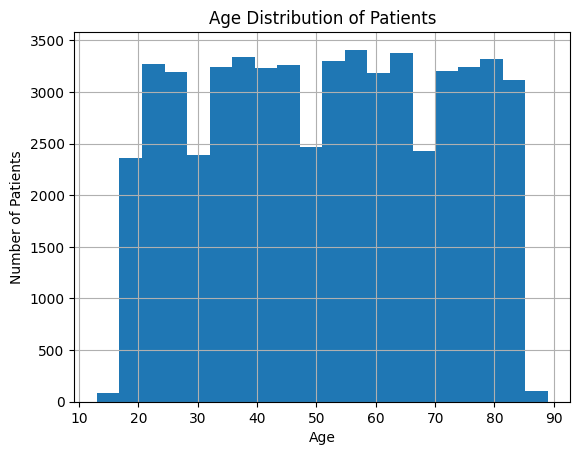

In [23]:
df["Age"].hist(bins=20)
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()




### Insight

The dataset contains mainly middle-aged and elderly patients, indicating higher healthcare demand among these age groups.

In [9]:
df["Length of Stay"].describe()

count    55500.000000
mean        15.509009
std          8.659600
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: Length of Stay, dtype: float64

### Billing Amount Statistics

The distribution of healthcare costs is analyzed to understand billing patterns.

In [50]:
df["Billing Amount"].describe()

count    54966.000000
mean     25594.632170
std      14162.191365
min          9.238787
25%      13326.001350
50%      25593.873000
75%      37819.858159
max      52764.276736
Name: Billing Amount, dtype: float64

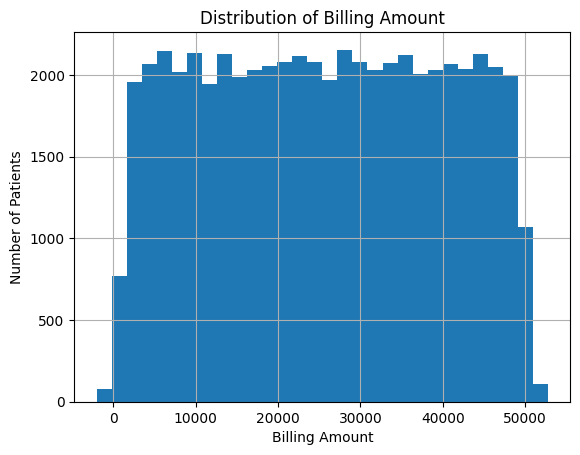

In [24]:
df["Billing Amount"].hist(bins=30)
plt.title("Distribution of Billing Amount")
plt.xlabel("Billing Amount")
plt.ylabel("Number of Patients")
plt.show()



### Insight

Billing amounts show the distribution of healthcare costs, with some variation between patients and a small number of extreme values.

### Healthcare Costs by Medical Condition

In [15]:
df.groupby("Medical Condition")["Billing Amount"].mean()




Medical Condition
Arthritis       25497.327056
Asthma          25635.249359
Cancer          25161.792707
Diabetes        25638.405577
Hypertension    25497.095761
Obesity         25805.971259
Name: Billing Amount, dtype: float64

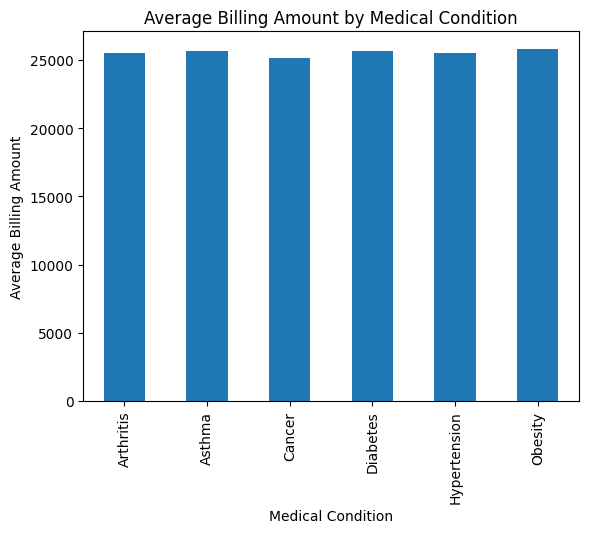

In [16]:
df.groupby("Medical Condition")["Billing Amount"].mean().plot(kind="bar")
plt.title("Average Billing Amount by Medical Condition")
plt.xlabel("Medical Condition")
plt.ylabel("Average Billing Amount")
plt.show()

# Average billing costs are fairly consistent across medical conditions,
# with only small variations between diseases.”

### Insight

Average billing costs are relatively similar across medical conditions, with only small differences between categories.

### Relationship Between Length of Stay and Billing Amount

In [17]:
df[["Length of Stay", "Billing Amount"]].corr()


,Length of Stay,Billing Amount
Length of Stay,1.000000,-0.005602
Billing Amount,-0.005602,1.000000


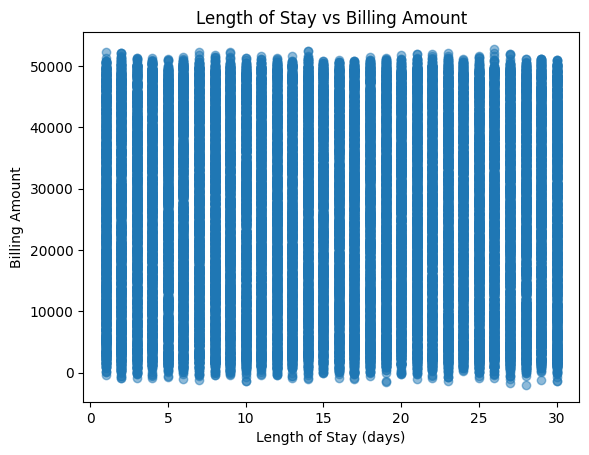

In [25]:
plt.scatter(df["Length of Stay"], df["Billing Amount"],alpha=0.5)
plt.title("Length of Stay vs Billing Amount")
plt.xlabel("Length of Stay (days)")
plt.ylabel("Billing Amount")
plt.show()

### Insight

No strong linear relationship was observed between hospital stay duration and billing amount.

### Billing Amount by Admission Type

In [19]:
df.groupby("Admission Type")["Billing Amount"].mean()

Admission Type
Elective     25602.226311
Emergency    25497.397157
Urgent       25517.364497
Name: Billing Amount, dtype: float64

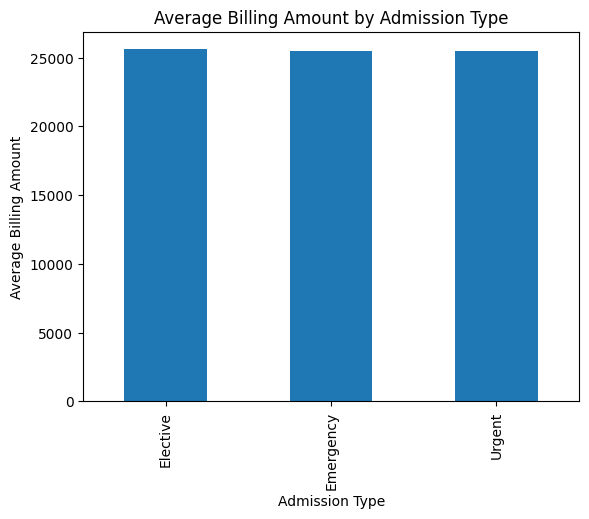

In [20]:
df.groupby("Admission Type")["Billing Amount"].mean().plot(kind="bar")
plt.title("Average Billing Amount by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Average Billing Amount")
plt.show()


### Insight
Elective admissions show slightly higher average billing amounts than urgent and emergency admissions.

### Correlation Analysis

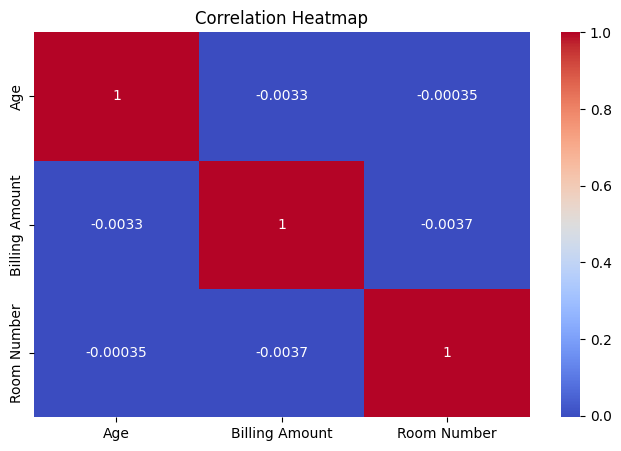

In [48]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Insight

No strong correlations were found between the numerical variables.

Key Findings

- A total of 534 duplicate records were identified and removed to improve data quality.
- Negative billing amounts were treated as invalid values and replaced using the median billing amount.
- A new feature, Length of Stay, was created to calculate the number of days each patient stayed in the hospital.
- Most patients in the dataset were middle-aged and elderly, indicating higher healthcare demand among these age groups.
- Average billing amounts were relatively similar across different medical conditions.
- No strong linear relationship was found between Length of Stay and Billing Amount.
- The correlation analysis showed no strong correlations among the main numerical variables.

Final Conclusion

This project performed an Exploratory Data Analysis (EDA) on a healthcare dataset using Python, Pandas, Matplotlib, and Seaborn.

The analysis included data loading, data quality assessment, data cleaning, feature engineering, descriptive statistics, data visualization, and correlation analysis. During the data cleaning process, duplicate records were removed, invalid billing values were replaced using the median, and a new Length of Stay feature was created to support further analysis.

The results showed that healthcare costs were relatively similar across different medical conditions, while elective admissions tended to have slightly higher average billing amounts. In addition, no strong linear relationship was observed between hospital stay duration and billing amount, and the correlation analysis indicated that the main numerical variables were only weakly related.

Overall, this project demonstrates a complete exploratory data analysis workflow and highlights the importance of data cleaning, feature engineering, and visualization in extracting meaningful insights from healthcare data.

